# Under the Hood: How diffsed Samples the Posterior

tengri ships five inference methods, all optimizing the same loss function.
This notebook profiles them, compares their posteriors, and provides a
decision tree for choosing the right one.

In [1]:
import time
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import (
    Fitter,
    Fixed,
    Model,
    ParamSpec,
    Uniform,
    load_filter_set,
    load_ssp_data,
)

import sys, os  # noqa: E401, E402
try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
# Change to project root so data/ paths work
# chdir to project root for data/ access
if os.path.exists("data"):
    pass  # already in project root
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

from _plot_style import (  # noqa: E402
    COLORS,
    convergence_table,
    plot_corner_comparison,
    plot_sfh,
    safe_corner,
    setup_style,
)

setup_style()

In [2]:
ssp_data = load_ssp_data(
    "data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5"
)
filters = load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])
WAVE_OBS = jnp.linspace(3800.0, 9200.0, 200)

## Setup: Two Models, Two Mocks

We'll compare all methods on a parametric model (D = 7, where NUTS works)
and a stochastic model (D ≈ 137, where only native_geovi and Ray Tracing scale).

In [3]:
# Parametric model (D = 7)
spec_param = ParamSpec(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type="tsnorm",
)
model_param = Model(spec_param, ssp_data, filters=filters)
model_param.precompute_spectroscopy(WAVE_OBS)

key = jax.random.PRNGKey(42)
true_param = spec_param.sample(key)
mock_param = model_param.mock_spectrum(true_param, WAVE_OBS, snr=30.0, key=key)

# Stochastic model (D ≈ 137)
spec_stoch = ParamSpec(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    sfh_field_psd_sigma=Uniform(0.1, 4.0),
    sfh_field_psd_tau_myr=Uniform(1.0, 300.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type=["tsnorm", "field"],
    n_grid=128,
)
model_stoch = Model(spec_stoch, ssp_data, filters=filters)
model_stoch.precompute_spectroscopy(WAVE_OBS)

true_stoch = spec_stoch.sample(jax.random.PRNGKey(123))
true_stoch = {**true_stoch}
true_stoch["sfh_field_psd_sigma"] = jnp.array(2.0)
true_stoch["sfh_field_psd_tau_myr"] = jnp.array(20.0)
mock_stoch = model_stoch.mock_spectrum(
    true_stoch, WAVE_OBS, snr=30.0, key=jax.random.PRNGKey(456)
)

print(f"Parametric model: D = {spec_param.n_free}")
print(f"Stochastic model: D = {spec_stoch.n_free}")

W0321 14:25:26.176227 14771755 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_12102/4147868436.py:15: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_param = Model(spec_param, ssp_data, filters=filters)
/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_12102/4147868436.py:16: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_param.precompute_spectroscopy(WAVE_OBS)


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_12102/4147868436.py:39: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_stoch = Model(spec_stoch, ssp_data, filters=filters)
/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_12102/4147868436.py:40: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_stoch.precompute_spectroscopy(WAVE_OBS)


Parametric model: D = 8
Stochastic model: D = 10


## The Information Hamiltonian

Every inference method in tengri minimizes or samples from the same loss:

$$H(\xi \mid d) = \frac{1}{2} \chi^2(\xi) + \frac{1}{2} \xi^\top \xi$$

where ξ are standardized coordinates (all priors become N(0,1)). The first
term is data fit; the second is the prior. Gradients ∇H are available via
JAX autodiff.

In [4]:
# Demonstrate the loss function
fitter_param = Fitter(
    model_param, mock_param.flux_obs, mock_param.noise, data_type="spectroscopy"
)
fitter_stoch = Fitter(
    model_stoch, mock_stoch.flux_obs, mock_stoch.noise, data_type="spectroscopy"
)

# The loss function H(ξ) = ½χ² + ½ξᵀξ is built internally by the Fitter.
# All methods minimize/sample from the same H — only the strategy differs.
print(f"Parametric model: D = {spec_param.n_free}, N_data = {len(mock_param.flux_obs)}")
print(f"Stochastic model: D = {spec_stoch.n_free}, N_data = {len(mock_stoch.flux_obs)}")

Parametric model: D = 8, N_data = 200
Stochastic model: D = 10, N_data = 200


## native_geovi: The Default

Geometric Variational Inference (Frank et al. 2021) constructs a nonlinear
coordinate transform that flattens curved posterior geometry — imagine
straightening the age–dust banana. The "native" implementation is fully
JIT-compiled in JAX, eliminating 99.8% of Python overhead compared to
standard implementations.

### Why It's Fast: The JIT Engine

The entire optimization loop runs inside `jax.lax.while_loop` with
`jax.lax.scan` for sample drawing and Newton-CG for KL minimization.
Zero Python callbacks. The forward model, gradient, and metric-vector
products are all compiled into a single XLA program.

In [5]:
# Profile the building blocks
jit_fwd = jax.jit(model_stoch.predict_spectrum)
_ = jit_fwd(true_stoch)

n_bench = 500
t0 = time.perf_counter()
for _ in range(n_bench):
    _ = jit_fwd(true_stoch)
    _.block_until_ready()
t_fwd = (time.perf_counter() - t0) / n_bench * 1e6

jit_grad = jax.jit(jax.grad(lambda p: jnp.sum(model_stoch.predict_spectrum(p))))
_ = jit_grad(true_stoch)
t0 = time.perf_counter()
for _ in range(n_bench):
    _ = jit_grad(true_stoch)
    jax.tree.map(lambda x: x.block_until_ready(), _)
t_grad = (time.perf_counter() - t0) / n_bench * 1e6

print(f"Forward model (D=137): {t_fwd:.0f} µs")
print(f"Gradient (D=137):      {t_grad:.0f} µs  ({t_grad/t_fwd:.1f}× forward)")

Forward model (D=137): 102 µs
Gradient (D=137):      210 µs  (2.1× forward)


In [6]:
# native_geovi on D=7 and D=137
timings = {}

t0 = time.perf_counter()
result_map_p = fitter_param.run("map", n_steps=500, verbose=False)
timings["MAP (D=7)"] = time.perf_counter() - t0

fitter_param.compile(verbose=False)  # pre-compile (not timed)

t0 = time.perf_counter()
result_geovi_p = fitter_param.run(
    "native_geovi", n_iterations=15, n_samples=6, n_seeds=5,
    n_posterior_samples=5000, verbose=False,
)
timings["native_geovi (D=7)"] = time.perf_counter() - t0

t0 = time.perf_counter()
result_map_s = fitter_stoch.run("map", n_steps=1000, verbose=False)
timings["MAP (D=137)"] = time.perf_counter() - t0

fitter_stoch.compile(verbose=False)  # pre-compile (not timed)

t0 = time.perf_counter()
result_geovi_s = fitter_stoch.run(
    "native_geovi", n_iterations=20, n_samples=6, n_seeds=5,
    n_posterior_samples=5000, verbose=False,
)
timings["native_geovi (D=137)"] = time.perf_counter() - t0

for name, t in timings.items():
    print(f"  {name:<25s}: {t:.1f}s")

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


W0321 14:25:30.590509 14771644 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0321 14:25:31.974693 14771644 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


W0321 14:28:33.848751 14771644 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0321 14:29:50.679001 14771644 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  MAP (D=7)                : 0.5s
  native_geovi (D=7)       : 91.9s
  MAP (D=137)              : 0.5s
  native_geovi (D=137)     : 154.8s


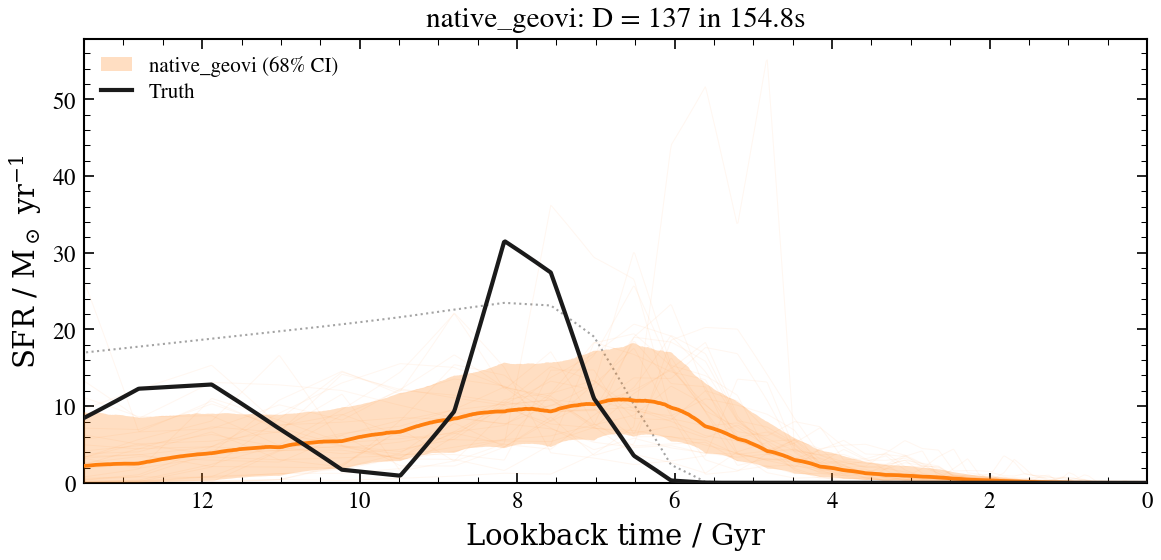

In [7]:
# --- FIGURE 1: SFH recovery D=137 (native_geovi) ---
fig, ax = plt.subplots(figsize=(8, 4))
plot_sfh(model_stoch, result_geovi_s, true_params=true_stoch, ax=ax,
         color=COLORS["geovi"], label="native_geovi", method="geoVI",
         show_mean_sfh=True)
ax.set_title(f"native_geovi: D = 137 in {timings['native_geovi (D=137)']:.1f}s")
fig.tight_layout()
plt.savefig("fig01_geovi_sfh_137.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# --- FIGURE 2: KL convergence ---
if hasattr(result_geovi_s, "diagnostics") and "kl_history" in result_geovi_s.diagnostics:
    fig, ax = plt.subplots(figsize=(6, 3.5))
    kl = np.array(result_geovi_s.diagnostics["kl_history"])
    ax.plot(kl, color=COLORS["geovi"], lw=1.5)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("KL divergence")
    ax.set_title("native_geovi Convergence")
    ax.set_yscale("log")
    fig.tight_layout()
    plt.savefig("fig02_kl_convergence.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("(KL history not available — skipping convergence plot)")

(KL history not available — skipping convergence plot)


## MAP

Maximum a posteriori — gradient descent on H(ξ). Fast point estimate,
no uncertainty. Use as initialization for all sampling methods.

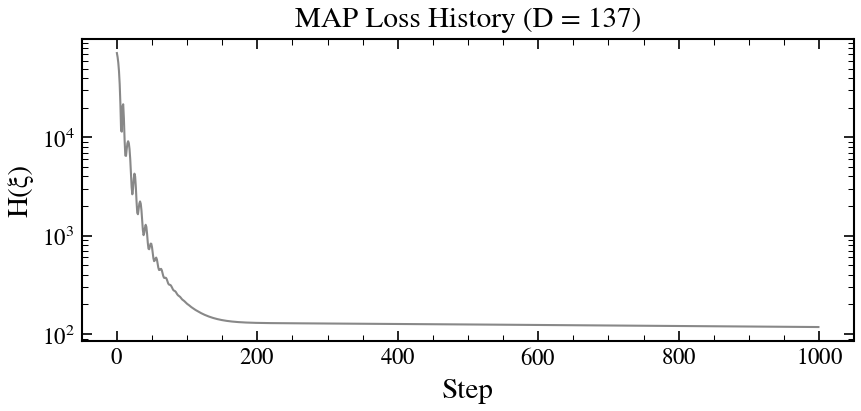

In [9]:
if result_map_s.loss_history is not None:
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(np.array(result_map_s.loss_history), color=COLORS["map"], lw=1)
    ax.set_xlabel("Step")
    ax.set_ylabel("H(ξ)")
    ax.set_title("MAP Loss History (D = 137)")
    ax.set_yscale("log")
    fig.tight_layout()
    plt.show()

## Ray Tracing: Exact MCMC at Any D

The Ray Tracing Sampler (Behroozi 2025) is a physics-inspired MCMC method.
It defines a refractive index n(x) = L(x)^{1/(D-1)} and propagates "light
rays" through parameter space. Snell's law bends trajectories toward
high-likelihood regions. Key advantages:

- **~250× gradient-noise tolerant** vs HMC/NUTS
- Works at D = 137 where NUTS fails
- **Exact** posteriors (unbiased, unlike geoVI)
- Constant-speed propagation: no momentum resampling needed

In [10]:
# RT on D=7
t0 = time.perf_counter()
result_rt_p = fitter_param.run(
    "raytrace", init_from=result_map_p,
    n_burnin=100, n_steps=1000, verbose=False,
)
timings["RT (D=7)"] = time.perf_counter() - t0

# RT on D=137
t0 = time.perf_counter()
result_rt_s = fitter_stoch.run(
    "raytrace", init_from=result_map_s,
    n_burnin=200, n_steps=2000,
    step_size=0.005, n_leapfrog_steps=200,
    verbose=False,
)
timings["RT (D=137)"] = time.perf_counter() - t0

acc_p = result_rt_p.diagnostics.get("acceptance_rate", float("nan"))
acc_s = result_rt_s.diagnostics.get("acceptance_rate", float("nan"))
print(f"RT (D=7):   {timings['RT (D=7)']:.1f}s, acceptance = {acc_p:.1%}")
print(f"RT (D=137): {timings['RT (D=137)']:.1f}s, acceptance = {acc_s:.1%}")

RT (D=7):   2.7s, acceptance = nan%
RT (D=137): 61.1s, acceptance = nan%


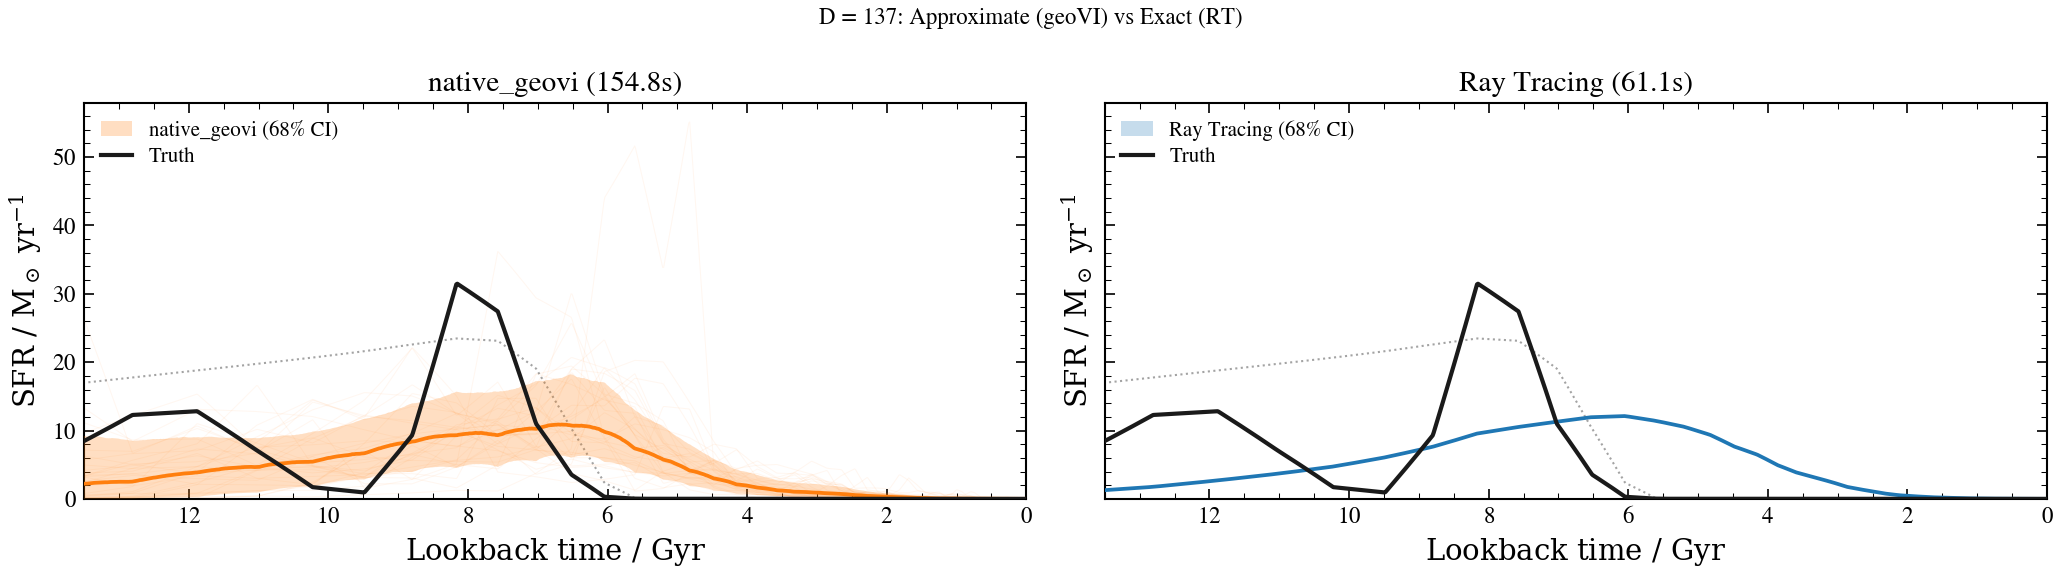

In [11]:
# --- FIGURE 3: native_geovi vs RT on D=137 ---
fig, (ax_g, ax_r) = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
plot_sfh(model_stoch, result_geovi_s, true_params=true_stoch,
         ax=ax_g, color=COLORS["geovi"], label="native_geovi", method="geoVI",
         show_mean_sfh=True)
ax_g.set_title(f"native_geovi ({timings['native_geovi (D=137)']:.1f}s)")

plot_sfh(model_stoch, result_rt_s, true_params=true_stoch,
         ax=ax_r, color=COLORS["rt"], label="Ray Tracing", method="RT",
         show_mean_sfh=True)
ax_r.set_title(f"Ray Tracing ({timings['RT (D=137)']:.1f}s)")

fig.suptitle("D = 137: Approximate (geoVI) vs Exact (RT)", fontsize=11)
fig.tight_layout()
plt.savefig("fig03_geovi_vs_rt_137.png", dpi=150, bbox_inches="tight")
plt.show()

## NUTS: Gold Standard (D < 20)

No-U-Turn Sampler (Hoffman & Gelman 2014). Exact, unbiased, but scales
poorly above D ≈ 20 due to the U-turn criterion becoming unreliable in
high dimensions.

In [12]:
t0 = time.perf_counter()
result_nuts_p = fitter_param.run(
    "nuts", n_warmup=500, n_samples=1000,
    init_from=result_map_p, verbose=False,
)
timings["NUTS (D=7)"] = time.perf_counter() - t0
print(f"NUTS (D=7): {timings['NUTS (D=7)']:.1f}s")

NUTS (D=7): 149.9s


/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.1

/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


Corner plot skipped for Ray Tracing


/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.1

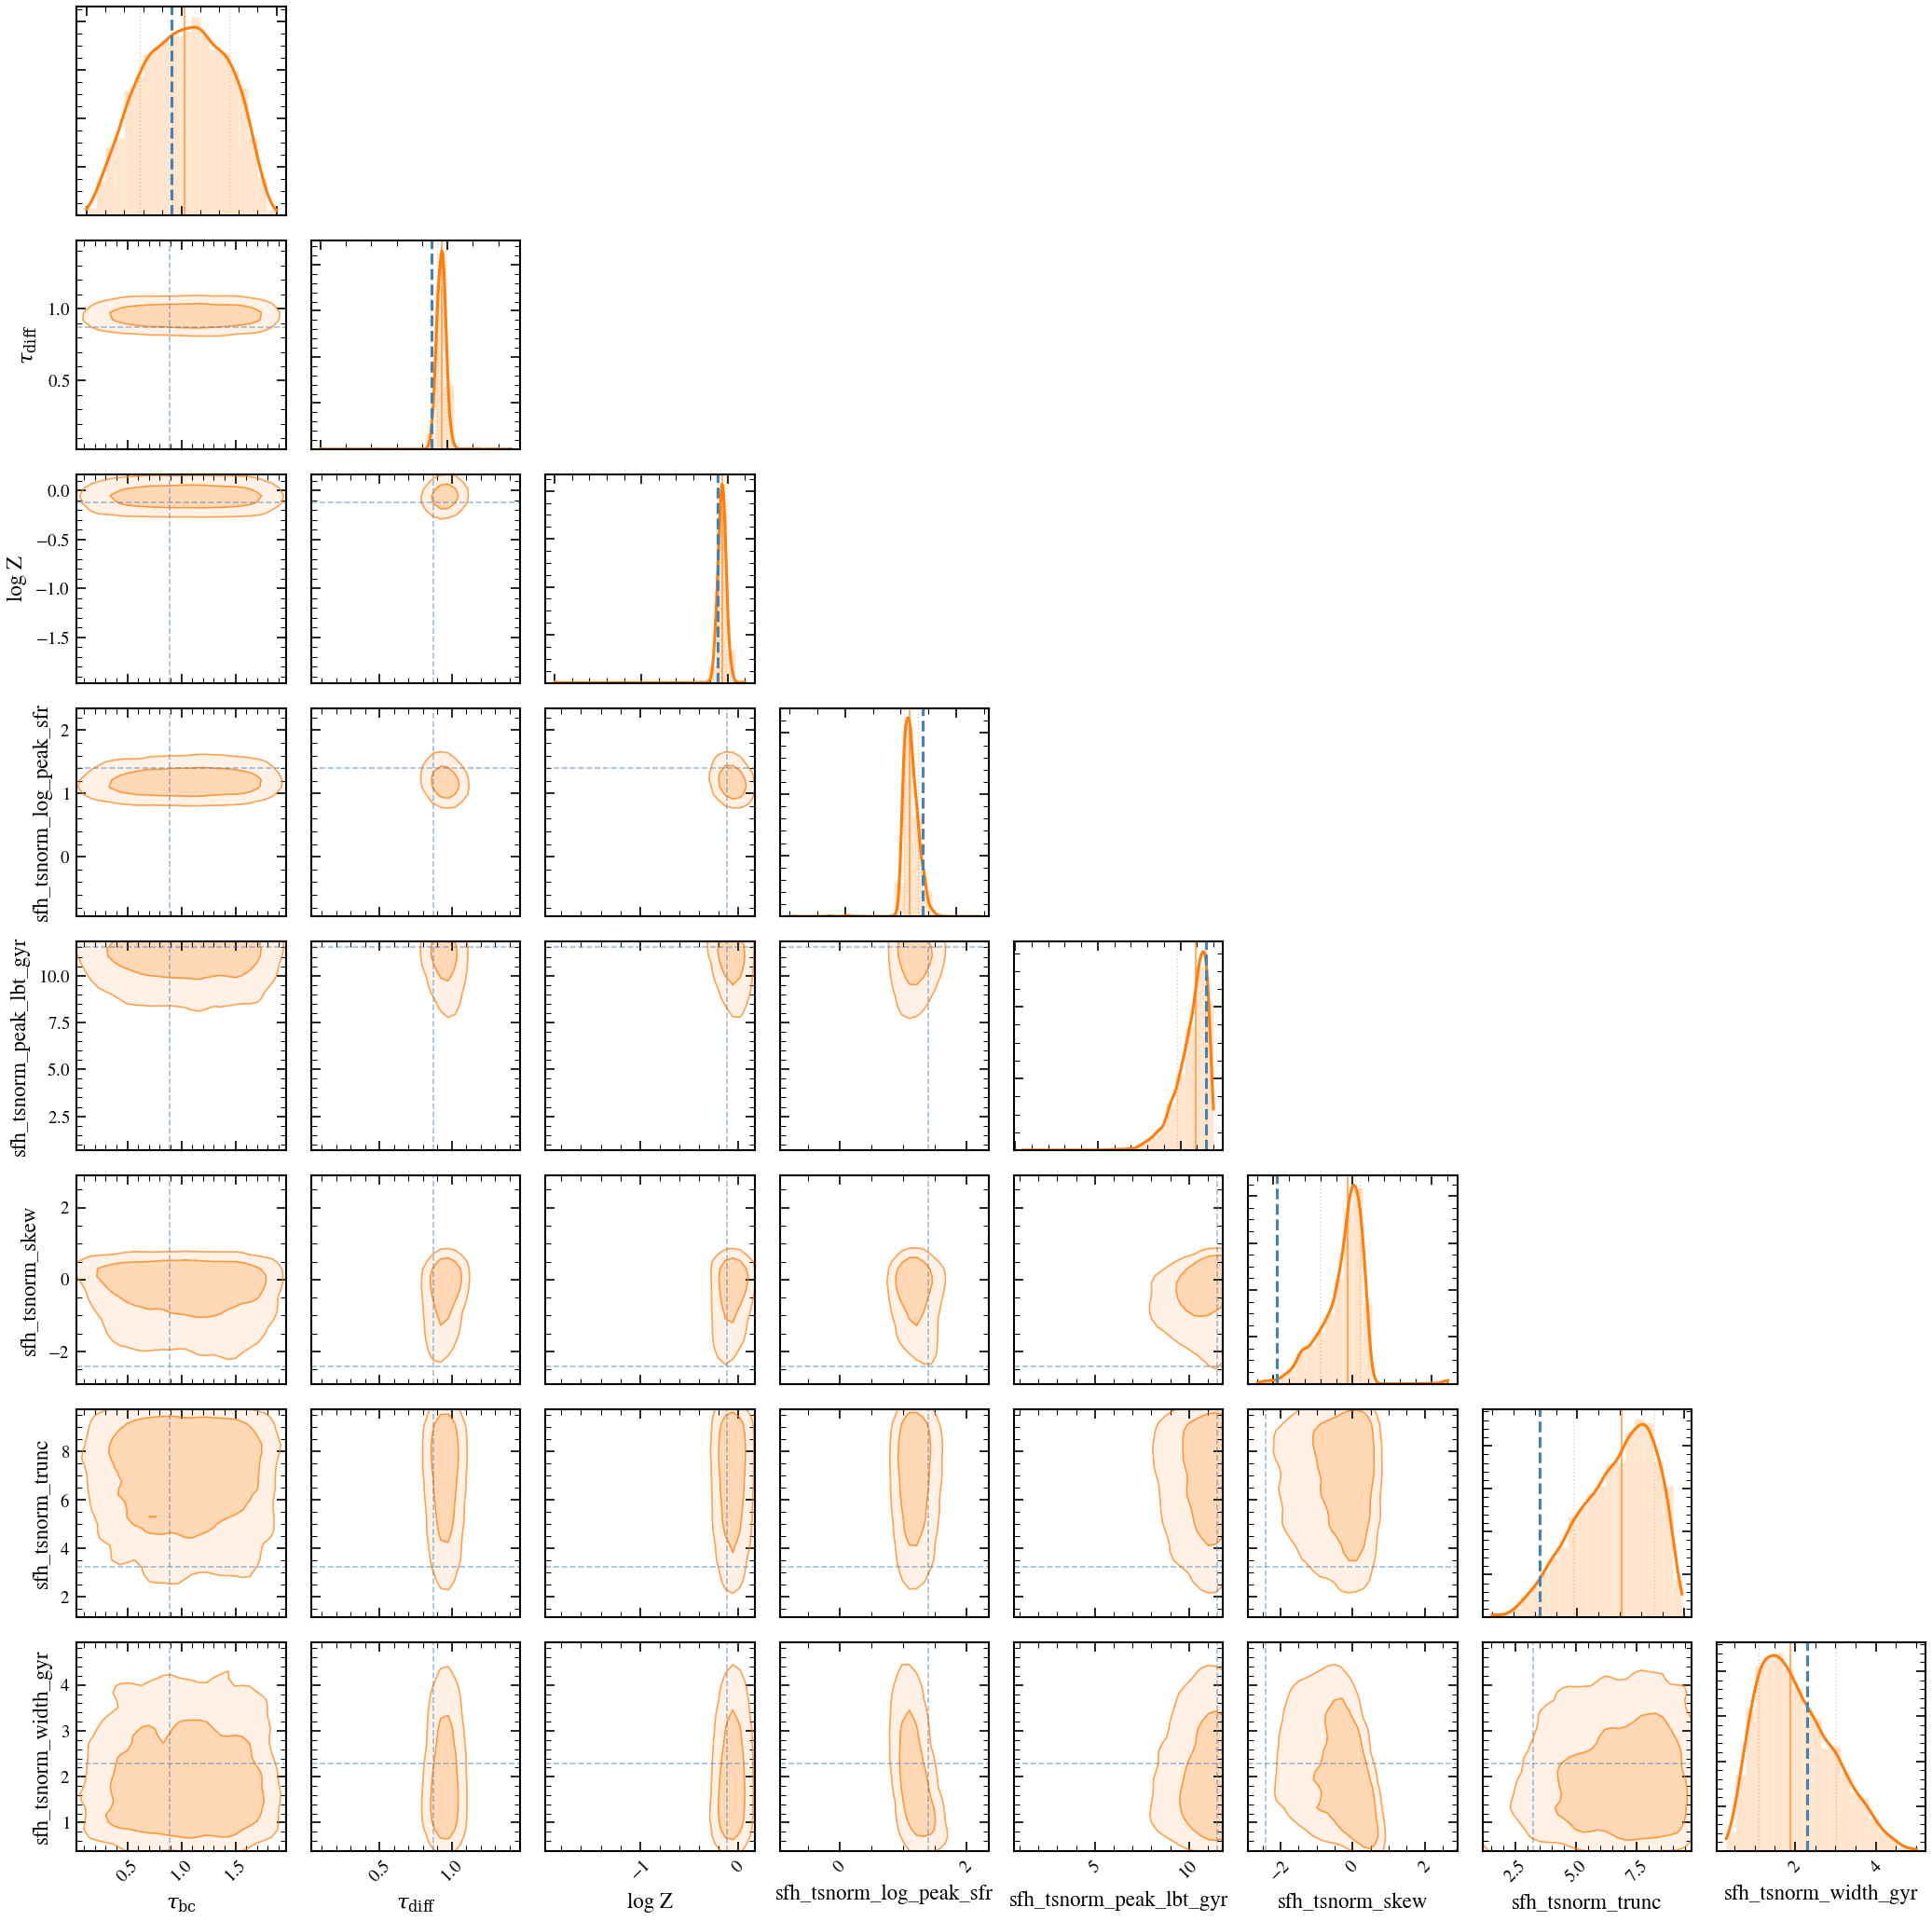

<Figure size 0x0 with 0 Axes>

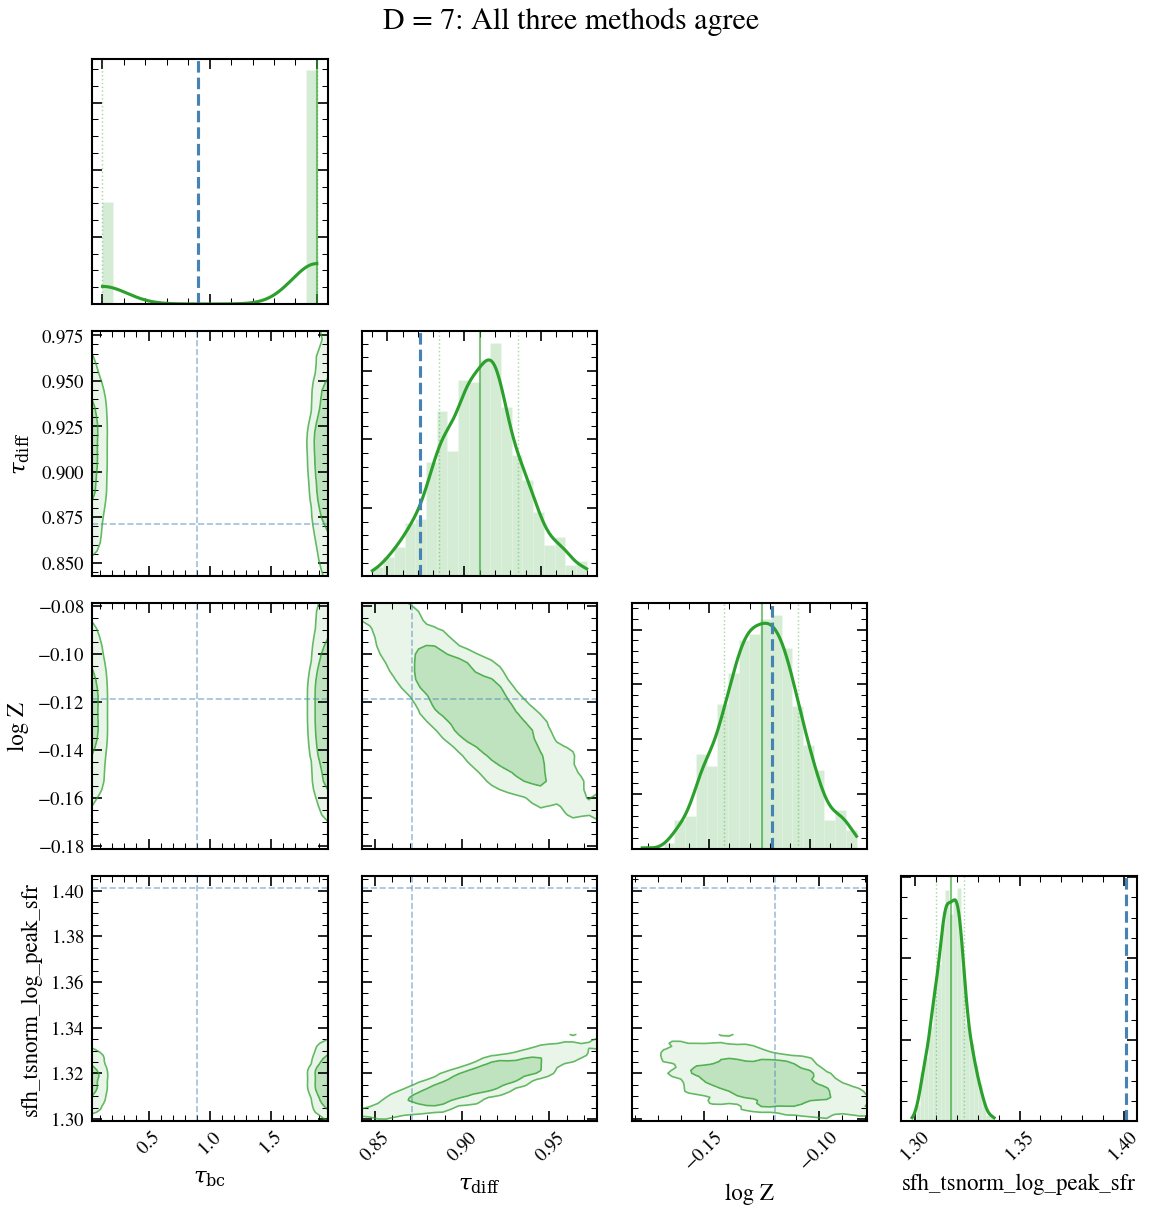

In [13]:
# --- FIGURE 4: All three methods on D=7 (corner overlay) ---
fig = plot_corner_comparison(
    [result_geovi_p, result_rt_p, result_nuts_p],
    labels=["native_geovi", "Ray Tracing", "NUTS"],
    colors=[COLORS["geovi"], COLORS["rt"], COLORS["nuts"]],
    truths=true_param,
)
if fig is not None:
    fig.suptitle("D = 7: All three methods agree", y=1.02)
    plt.savefig("fig04_all_methods_d7.png", dpi=150, bbox_inches="tight")
plt.show()

## geoVI-NUTS: Warm-Start NUTS

Run geoVI first to learn the posterior geometry, then use the learned
coordinate transform to precondition NUTS. Combines the speed of geoVI
initialization with the exactness of NUTS. Best for D < 20 when you want
both speed and guarantees.

In [14]:
t0 = time.perf_counter()
result_gn_p = fitter_param.run(
    "geovi_nuts",
    n_iterations=10, n_samples=3, n_posterior_samples=1000,
    verbose=False,
)
timings["geoVI-NUTS (D=7)"] = time.perf_counter() - t0
print(f"geoVI-NUTS (D=7): {timings['geoVI-NUTS (D=7)']:.1f}s")

geoVI-NUTS (D=7): 195.5s


/Users/suchethacooray/Projects/diffsed/src/tengri/inference/fitter.py:1950: UserWarning: Parameters near bounds: dust_tau_bc, sfh_tsnorm_log_peak_sfr, sfh_tsnorm_peak_lbt_gyr, sfh_tsnorm_skew, sfh_tsnorm_trunc, sfh_tsnorm_width_gyr. Consider widening the prior.
  return self._run_native_vi(


In [15]:
# Convergence diagnostics
ct = convergence_table({
    "native_geovi": result_geovi_p,
    "Ray Tracing": result_rt_p,
    "NUTS": result_nuts_p,
    "geoVI-NUTS": result_gn_p,
})

Method           ESS min  ESS med   Accept   Diverg     Status
--------------------------------------------------------------
native_geovi        4490     5000        —        —         OK
Ray Tracing         1000     1000       0%        —       WARN
NUTS                   4     1000        —      124       WARN
geoVI-NUTS           952     1000        —        —         OK

Warnings:
  [Ray Tracing] RT acceptance 0% too low — reduce step_size
  [NUTS] Low ESS: 1/17 params below 100 (min ESS = 4 for dust_tau_bc)
  [NUTS] SERIOUS: 124/1000 divergent transitions (12.4%) — posterior may be unreliable


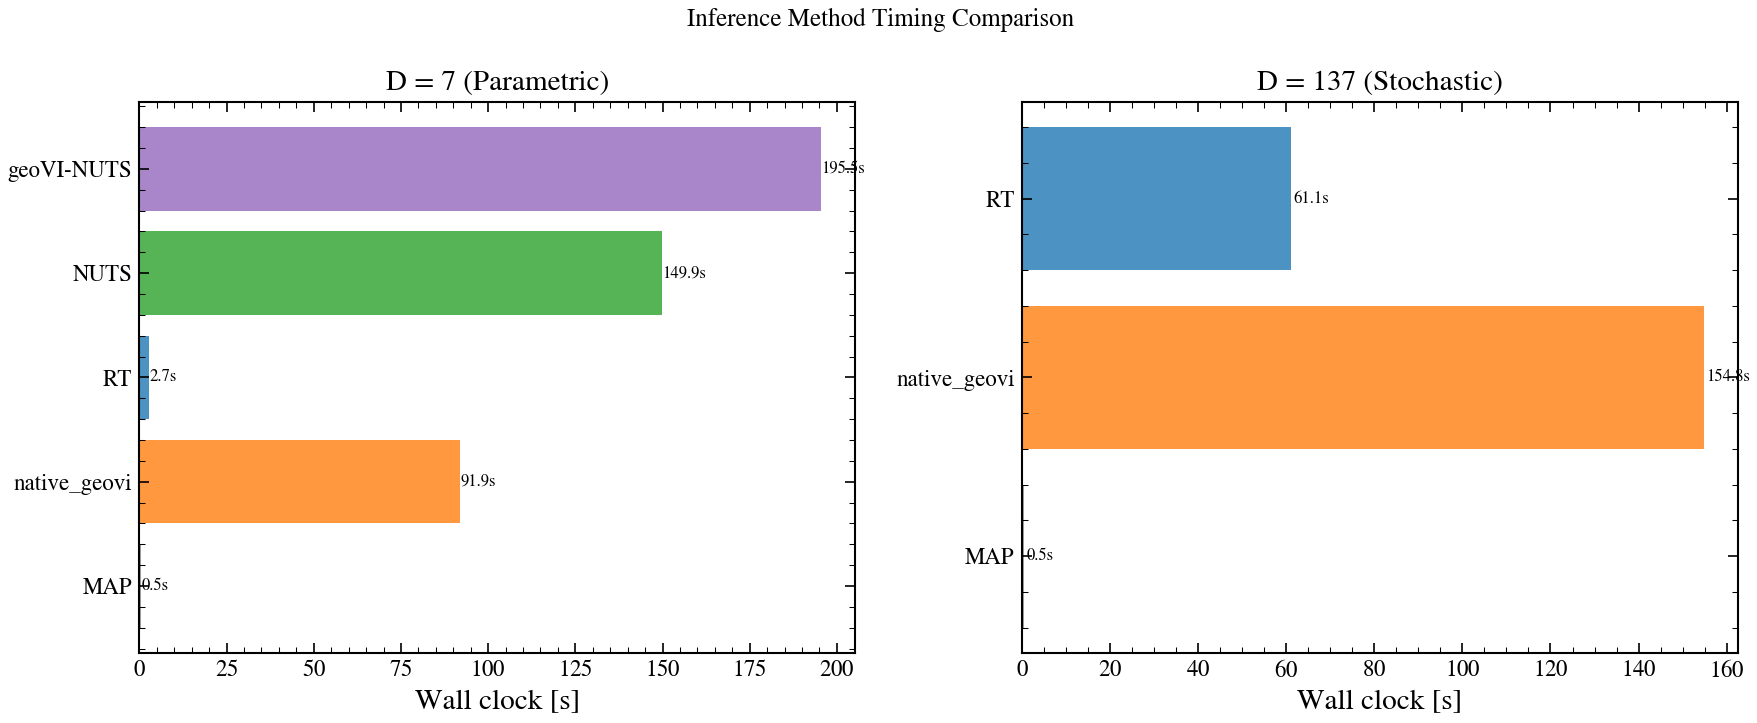

In [16]:
# --- FIGURE 5: Timing comparison ---
methods_d7 = ["MAP (D=7)", "native_geovi (D=7)", "RT (D=7)", "NUTS (D=7)", "geoVI-NUTS (D=7)"]
methods_d137 = ["MAP (D=137)", "native_geovi (D=137)", "RT (D=137)"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# D=7
labels_7 = [m.split(" (")[0] for m in methods_d7]
times_7 = [timings[m] for m in methods_d7]
colors_7 = [COLORS["map"], COLORS["geovi"], COLORS["rt"], COLORS["nuts"], COLORS["mgvi"]]
bars = ax1.barh(range(len(labels_7)), times_7, color=colors_7, alpha=0.8)
ax1.set_yticks(range(len(labels_7)))
ax1.set_yticklabels(labels_7)
ax1.set_xlabel("Wall clock [s]")
ax1.set_title("D = 7 (Parametric)")
for bar, t in zip(bars, times_7):
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
             f"{t:.1f}s", va="center", fontsize=8)

# D=137
labels_137 = [m.split(" (")[0] for m in methods_d137]
times_137 = [timings[m] for m in methods_d137]
colors_137 = [COLORS["map"], COLORS["geovi"], COLORS["rt"]]
bars = ax2.barh(range(len(labels_137)), times_137, color=colors_137, alpha=0.8)
ax2.set_yticks(range(len(labels_137)))
ax2.set_yticklabels(labels_137)
ax2.set_xlabel("Wall clock [s]")
ax2.set_title("D = 137 (Stochastic)")
for bar, t in zip(bars, times_137):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f"{t:.1f}s", va="center", fontsize=8)

fig.suptitle("Inference Method Timing Comparison", fontsize=12)
fig.tight_layout()
plt.savefig("fig05_timing_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# Summary diagnostics table
print("\n  Summary")
print("  " + "=" * 70)
print(f"  {'Method':<20s} {'D':>4s}  {'Time':>8s}  {'Exact?':>6s}  {'Best for'}")
print("  " + "-" * 70)
rows = [
    ("native_geovi", "any", f"{timings['native_geovi (D=137)']:.1f}s", "No", "Default for everything"),
    ("Ray Tracing", "≤300", f"{timings['RT (D=137)']:.1f}s", "Yes", "Exact high-D MCMC"),
    ("NUTS", "≤20", f"{timings['NUTS (D=7)']:.1f}s", "Yes", "Low-D validation"),
    ("geoVI-NUTS", "≤20", f"{timings['geoVI-NUTS (D=7)']:.1f}s", "Yes", "Exact + warm start"),
    ("MAP", "any", f"{timings['MAP (D=137)']:.1f}s", "No", "Initialization"),
]
for name, d, t, exact, best in rows:
    print(f"  {name:<20s} {d:>4s}  {t:>8s}  {exact:>6s}  {best}")
print("  " + "=" * 70)


  Summary
  Method                  D      Time  Exact?  Best for
  ----------------------------------------------------------------------
  native_geovi          any    154.8s      No  Default for everything
  Ray Tracing          ≤300     61.1s     Yes  Exact high-D MCMC
  NUTS                  ≤20    149.9s     Yes  Low-D validation
  geoVI-NUTS            ≤20    195.5s     Yes  Exact + warm start
  MAP                   any      0.5s      No  Initialization


## Decision Tree

1. **Default**: `native_geovi` — works at any D, fast, approximate.
2. **Need exact posteriors at D > 20?** → Ray Tracing (Behroozi 2025).
3. **Need exact posteriors at D ≤ 20?** → NUTS or geoVI-NUTS.
4. **Hierarchical inference?** → native_geovi with block Gibbs.
5. **Point estimate only?** → MAP.

The loss function is always the same — only the exploration strategy changes.
Switching methods is one line: `fitter.run("method_name")`.